여기서는 일단 지표 계산만 해보자

In [1]:
import os, csv, cv2, numpy as np, math
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor, as_completed

# 📂 정제된 mask 이미지 폴더 (흑백 이미지)
MASK_DIR = '/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/병해충/무름병/20251001_masks_cleaned'
OUT_CSV = '/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/병해충/무름병/251101_masks_cleaned_result.csv'
N_WORKERS = 8

# ✅ 흰색(255) 픽셀 면적 계산 함수
def calc_area(mask_path):
    try:
        img = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            return None

        # 전체 픽셀 수, 흰색 픽셀 수
        total_px = img.size
        white_px = np.count_nonzero(img)
        ratio = white_px / total_px

        # 형상지표 계산 (contour 기반)
        cnts, _ = cv2.findContours(img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if not cnts:
            return None
        cnt = max(cnts, key=cv2.contourArea)
        area = cv2.contourArea(cnt)
        perim = cv2.arcLength(cnt, True) + 1e-6
        circularity = 4 * math.pi * area / (perim * perim)
        hull = cv2.convexHull(cnt)
        hull_area = cv2.contourArea(hull) + 1e-6
        solidity = area / hull_area
        concavity = (hull_area - area) / hull_area

        pts = cnt[:, 0, :].astype(np.float32)
        dif1 = np.diff(pts, axis=0, prepend=pts[-1:])
        ang = np.arctan2(dif1[:, 1], dif1[:, 0])
        dtheta = np.diff(ang, prepend=ang[-1:])
        dtheta = (dtheta + np.pi) % (2*np.pi) - np.pi
        curvature = np.mean(np.abs(dtheta))
        roughness = (perim * perim) / (4 * math.pi * area) if area > 0 else np.nan

        return dict(
            filename=os.path.basename(mask_path),
            total_px=int(total_px),
            white_px=int(white_px),
            white_ratio=float(ratio),
            area_px=float(area),
            perim_px=float(perim),
            circularity=float(circularity),
            solidity=float(solidity),
            concavity=float(concavity),
            curvature=float(curvature),
            roughness=float(roughness)
        )
    except Exception as e:
        print(f'Error {mask_path}: {e}')
        return None

# ✅ 전체 mask 폴더 병렬 처리
def main():
    mask_files = [os.path.join(MASK_DIR, f) for f in os.listdir(MASK_DIR) if f.lower().endswith(('.png','.jpg','.jpeg'))]
    results = []
    with ThreadPoolExecutor(max_workers=N_WORKERS) as ex:
        futs = {ex.submit(calc_area, m): m for m in mask_files}
        for fu in tqdm(as_completed(futs), total=len(futs)):
            r = fu.result()
            if r: results.append(r)

    # CSV 저장
    cols = ['filename','total_px','white_px','white_ratio','area_px','perim_px','circularity','solidity','concavity','curvature','roughness']
    with open(OUT_CSV, 'w', newline='', encoding='utf-8') as f:
        wr = csv.DictWriter(f, fieldnames=cols)
        wr.writeheader()
        for r in results:
            wr.writerow(r)

if __name__ == '__main__':
    main()

100%|██████████| 1998/1998 [00:44<00:00, 44.81it/s] 


아주 간단한 시각화

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df=pd.read_csv("/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/병해충/무름병/251101_masks_cleaned_result.csv")
df.head()

,filename,total_px,white_px,white_ratio,area_px,perim_px,circularity,solidity,concavity,curvature,roughness
0,KakaoTalk_20251001_111343319_09_mask.png,65536,29274,0.446686,28815.5,978.825462,0.377942,0.807813,0.192187,0.822142,2.645906
1,IMG_5375_mask.png,65536,31359,0.478500,30062.0,1225.896529,0.251374,0.765531,0.234469,0.828403,3.978138
2,KakaoTalk_20251001_112622104_18_mask.png,65536,26499,0.404343,16719.5,643.688380,0.507086,0.872807,0.127193,0.842214,1.972051
3,KakaoTalk_20251001_112552939_09_mask.png,65536,21987,0.335495,13545.0,587.102594,0.493811,0.855087,0.144913,0.830462,2.025066
4,IMG_5922_mask.png,65536,21306,0.325104,20089.0,924.357426,0.295453,0.741894,0.258106,0.846633,3.384634


In [3]:
df.columns

Index(['filename', 'total_px', 'white_px', 'white_ratio', 'area_px',
       'perim_px', 'circularity', 'solidity', 'concavity', 'curvature',
       'roughness'],
      dtype='object')

In [6]:
feature=['white_px', 'white_ratio', 'area_px', 'perim_px', 'circularity', 'solidity', 'concavity', 'curvature', 'roughness']

In [5]:
df.describe().round(2)

,total_px,white_px,white_ratio,area_px,perim_px,circularity,solidity,concavity,curvature,roughness
count,1858.00,1858.00,1858.00,1858.00,1858.00,1858.00,1858.00,1858.00,1858.00,1858.00
mean,176495.60,136583.06,0.39,132404.78,973.24,0.38,0.80,0.20,0.84,2.82
std,1155005.98,1157858.43,0.12,1158576.31,1286.05,0.11,0.07,0.07,0.05,0.86
min,65536.00,27.00,0.00,16.00,20.00,0.13,0.40,0.00,0.80,1.23
25%,65536.00,21987.00,0.34,17693.50,743.77,0.30,0.76,0.15,0.82,2.19
50%,65536.00,25799.00,0.39,21451.50,838.20,0.38,0.81,0.19,0.83,2.63
75%,65536.00,29759.00,0.45,25422.25,964.18,0.46,0.85,0.24,0.84,3.28
max,12192768.00,12191767.00,1.00,12185703.00,14245.20,0.82,1.00,0.60,1.57,7.48


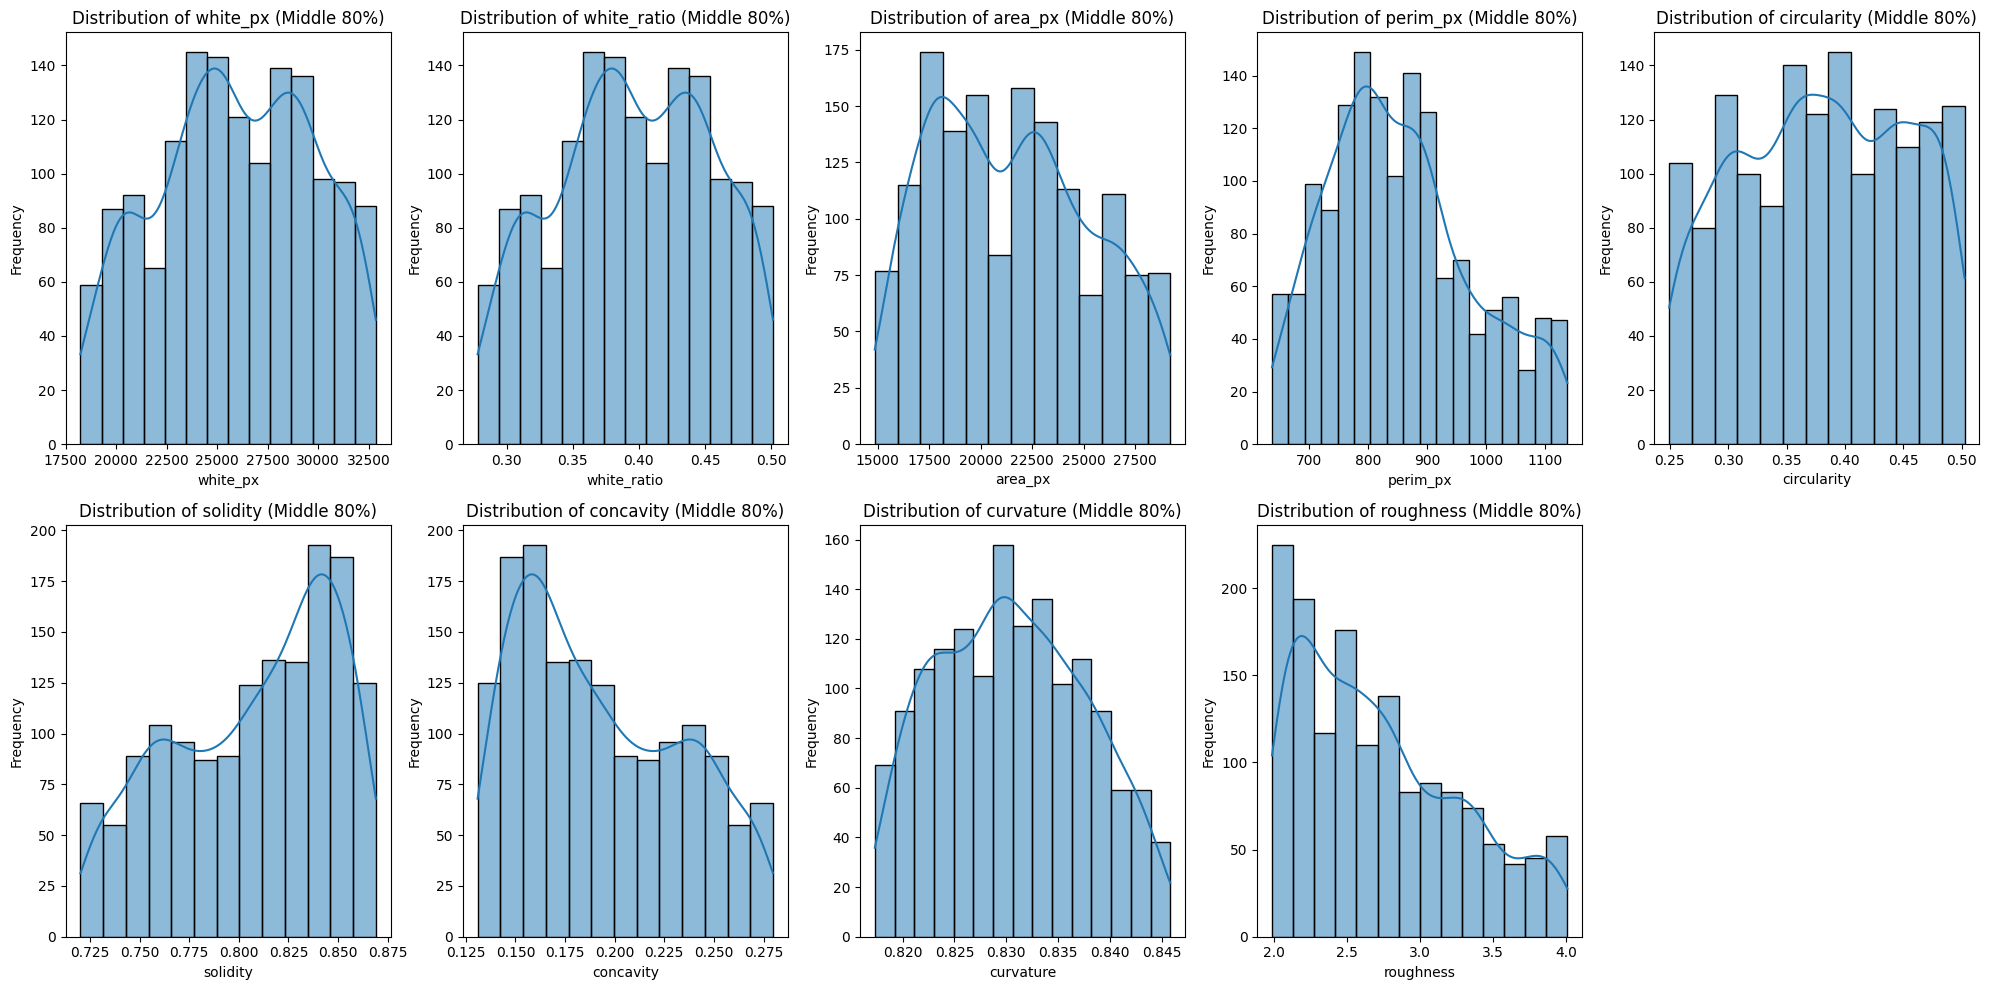

In [11]:
import seaborn as sns

fig, axes = plt.subplots(2, 5, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(feature):
    # Calculate the lower and upper bounds for the middle 80% of data
    lower_bound = df[col].quantile(0.1)
    upper_bound = df[col].quantile(0.9)

    # Filter the DataFrame
    df_filtered = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

    # Plot the distribution
    sns.histplot(df_filtered[col], kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col} (Middle 80%)')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

# Remove any unused subplots
for j in range(len(feature), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

지표분석

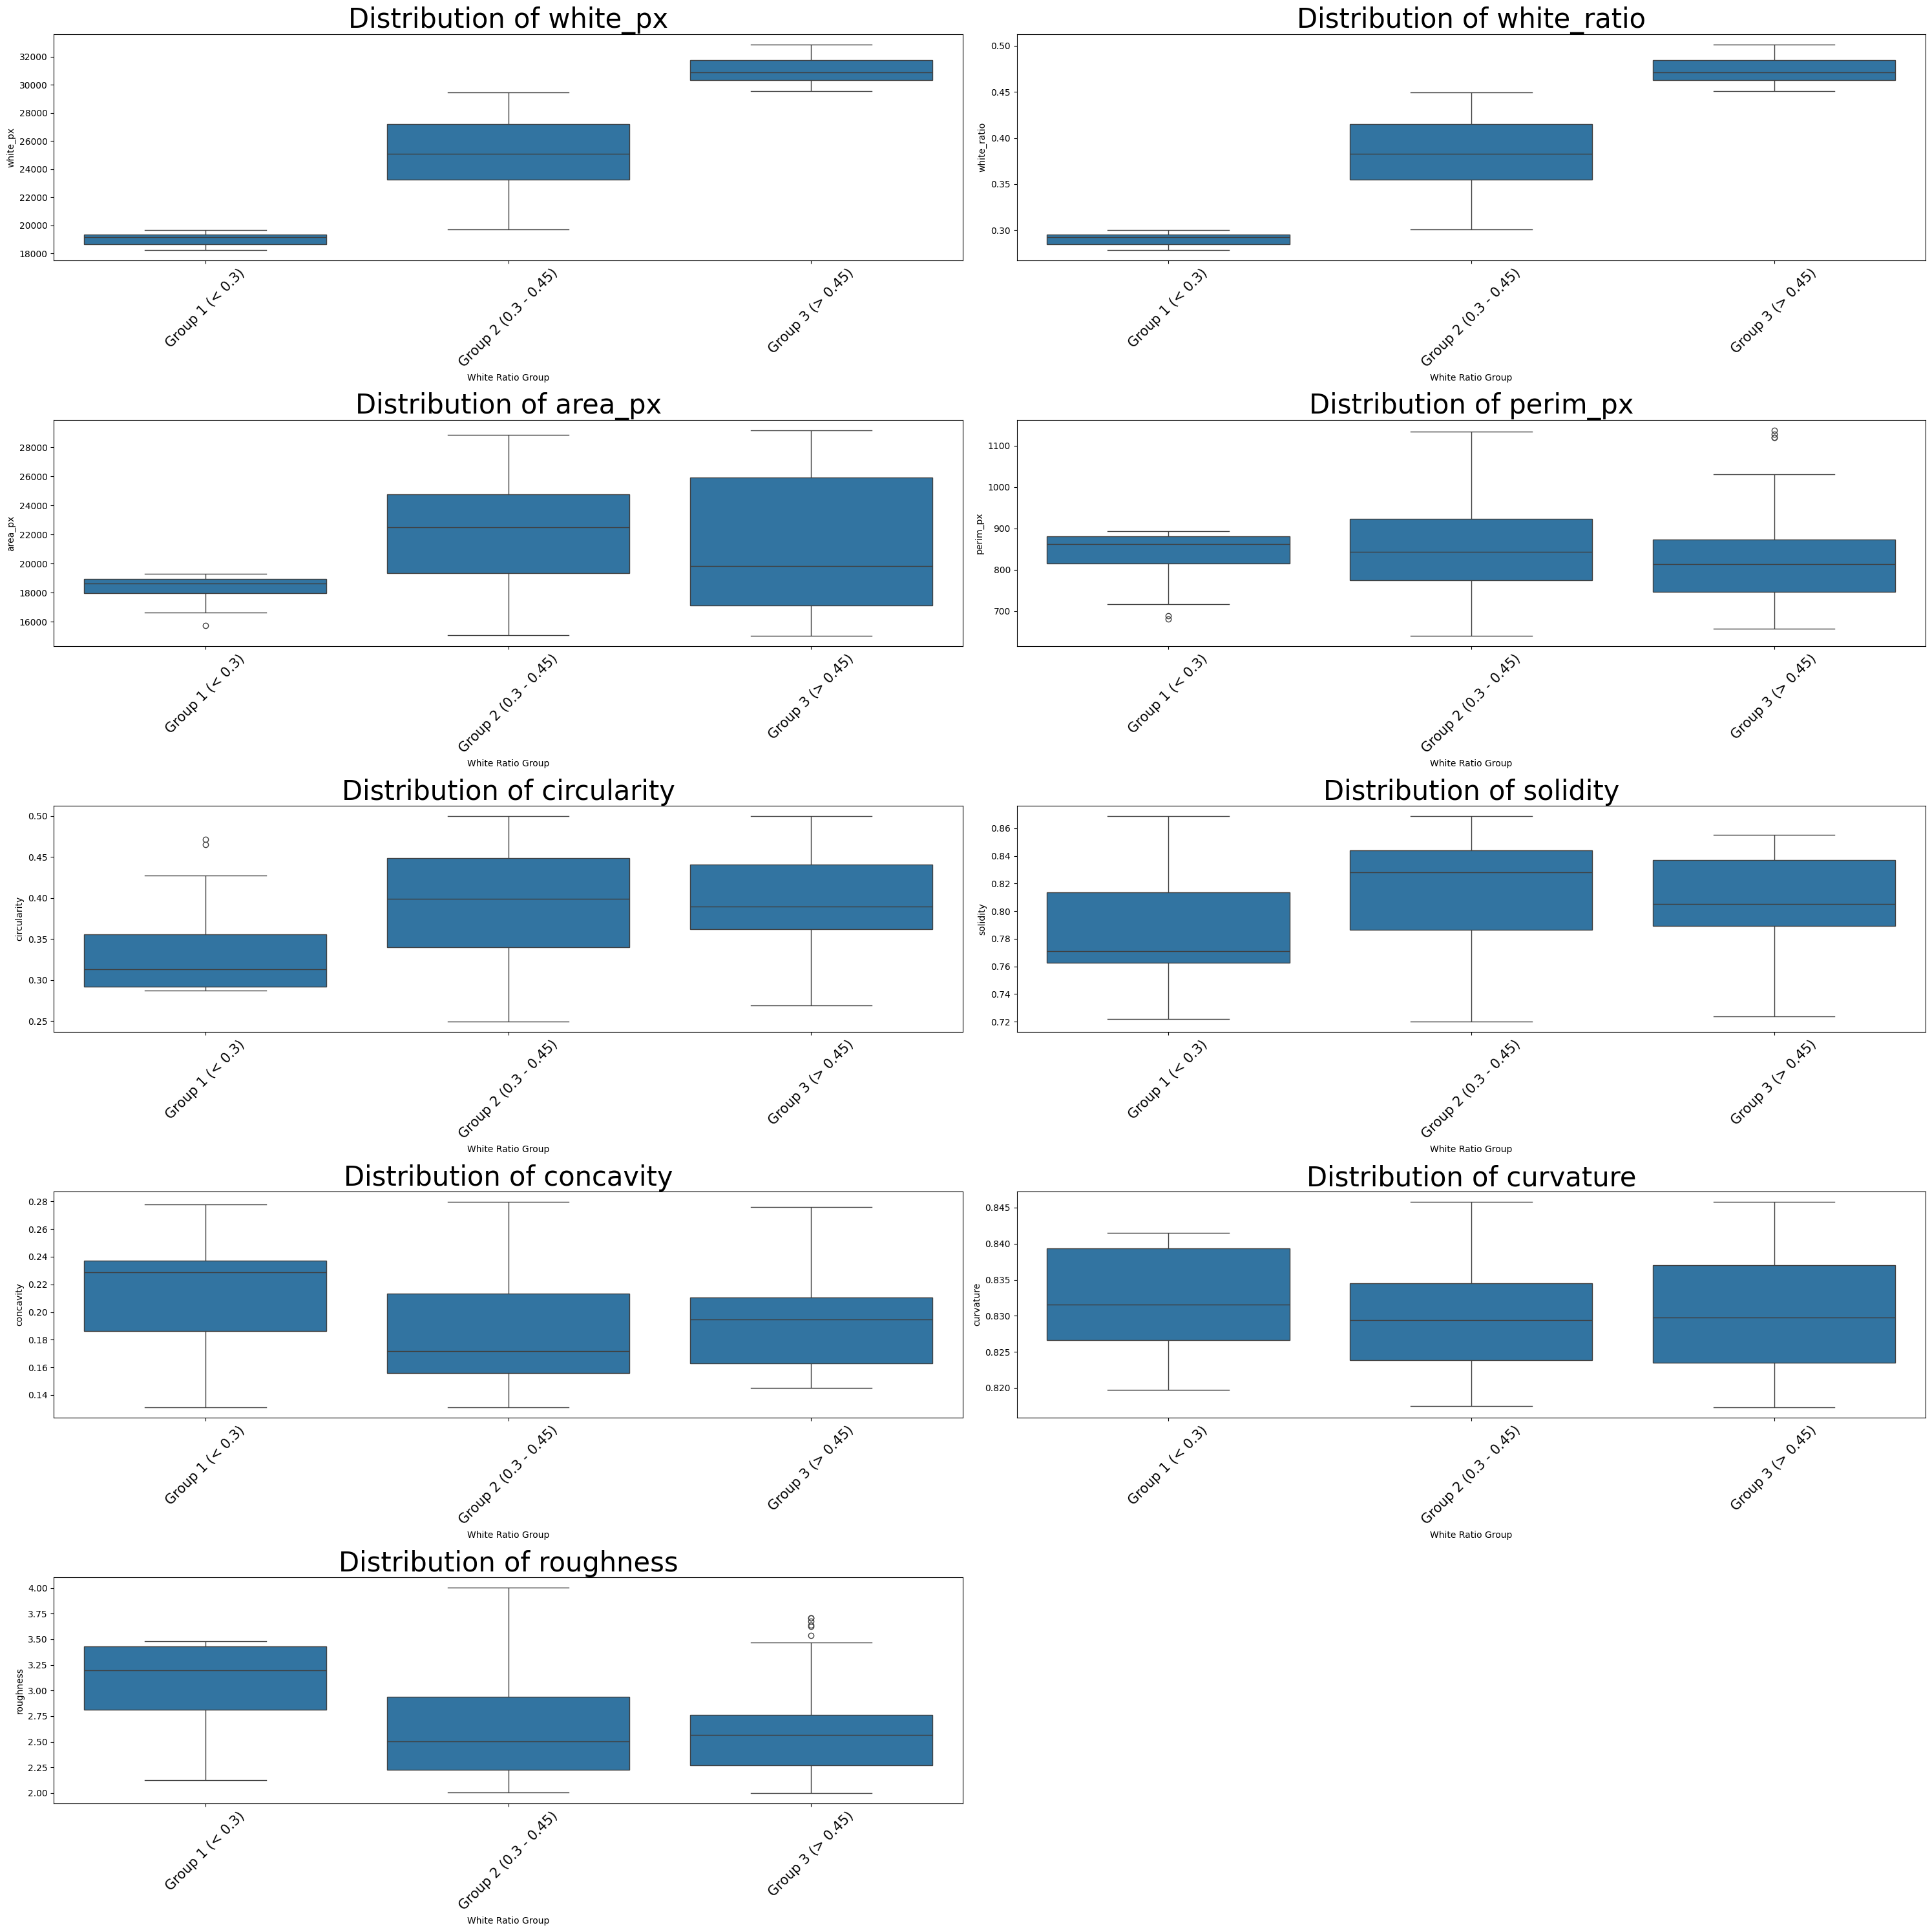

In [23]:
# Filter the data by removing the top and bottom 10% for each feature
df_filtered_overall = pd.DataFrame()
for col in feature:
    lower_bound = df[col].quantile(0.1)
    upper_bound = df[col].quantile(0.9)
    df_col_filtered = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)].copy()
    if df_filtered_overall.empty:
        df_filtered_overall = df_col_filtered
    else:
        df_filtered_overall = pd.merge(df_filtered_overall, df_col_filtered, on=df.columns.tolist(), how='inner')


# Define the groups based on 'white_ratio' using the filtered data
def group_white_ratio(ratio):
    if ratio < 0.3:
        return 'Group 1 (< 0.3)'
    elif 0.3 <= ratio < 0.45:
        return 'Group 2 (0.3 - 0.45)'
    else:
        return 'Group 3 (> 0.45)'

df_filtered_overall['white_ratio_group'] = df_filtered_overall['white_ratio'].apply(group_white_ratio)

# Visualize using box plots
fig, axes = plt.subplots(5, 2, figsize=(30, 30))
axes = axes.flatten()
group_order = ['Group 1 (< 0.3)', 'Group 2 (0.3 - 0.45)', 'Group 3 (> 0.45)']

for i, col in enumerate(feature):
    sns.boxplot(x='white_ratio_group', y=col, data=df_filtered_overall, order=group_order, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}', fontsize=30)
    axes[i].set_xlabel('White Ratio Group')
    axes[i].set_ylabel(col)
    axes[i].tick_params(axis='x', rotation=45, labelsize=15) # Rotate labels for better readability

# Remove any unused subplots
for j in range(len(feature), len(axes)):
    fig.delaxes(axes[j])


plt.tight_layout()
plt.show()

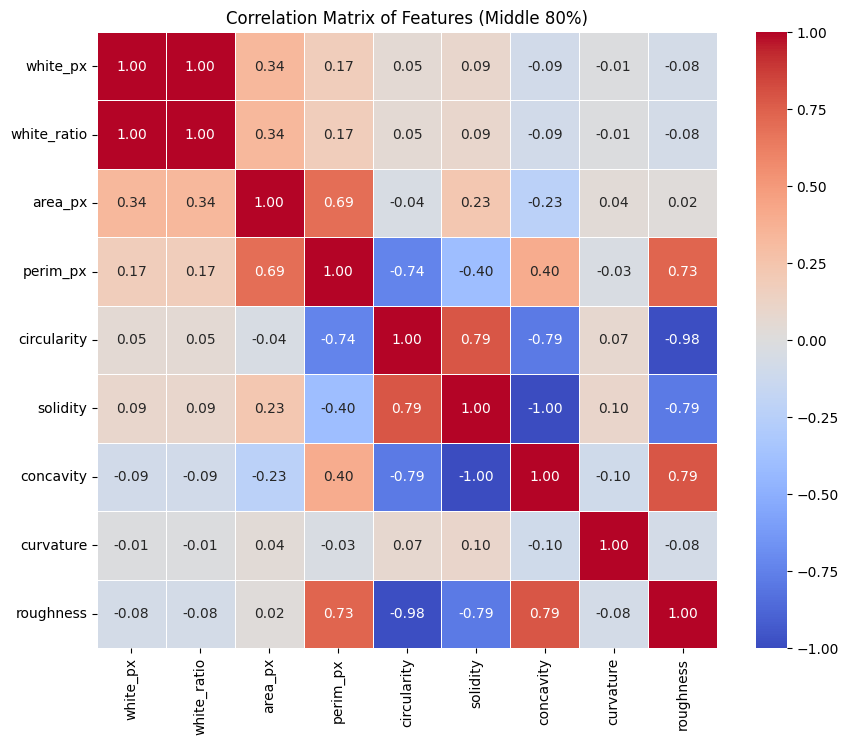

유의성 검정

In [25]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

# 숫자형 변수 목록
num_cols = feature
category_col = 'white_ratio_group'  # 올바른 범주 열 이름입니다.
anova_tables = []

# 각 숫자형 변수에 대해 ANOVA 수행
for col in num_cols:
    # 공식에서 category_col을 직접 사용합니다.
    model = ols(f'Q("{col}") ~ C(Q("{category_col}"))', data=df_filtered_overall).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)
    anova_tables.append((col, anova_table))
    print(f"\n[{col}] ANOVA 결과")
    print(anova_table)

# 전체 결과를 하나로 합친 DataFrame으로 정리
anova_results_df = pd.concat({col: table for col, table in anova_tables}, axis=0)

anova_results_df


[white_px] ANOVA 결과
                                 sum_sq     df           F         PR(>F)
C(Q("white_ratio_group"))  5.884393e+09    2.0  483.186587  1.431556e-137
Residual                   4.786073e+09  786.0         NaN            NaN

[white_ratio] ANOVA 결과
                             sum_sq     df           F         PR(>F)
C(Q("white_ratio_group"))  1.370067    2.0  483.186587  1.431556e-137
Residual                   1.114345  786.0         NaN            NaN

[area_px] ANOVA 결과
                                 sum_sq     df          F        PR(>F)
C(Q("white_ratio_group"))  6.273835e+08    2.0  24.965156  3.077667e-11
Residual                   9.876233e+09  786.0        NaN           NaN

[perim_px] ANOVA 결과
                                 sum_sq     df         F    PR(>F)
C(Q("white_ratio_group"))  8.021591e+04    2.0  3.649159  0.026455
Residual                   8.638937e+06  786.0       NaN       NaN

[circularity] ANOVA 결과
                             sum_sq     d

sum_sq     df           F  \
white_px    C(Q("white_ratio_group"))  5.884393e+09    2.0  483.186587   
            Residual                   4.786073e+09  786.0         NaN   
white_ratio C(Q("white_ratio_group"))  1.370067e+00    2.0  483.186587   
            Residual                   1.114345e+00  786.0         NaN   
area_px     C(Q("white_ratio_group"))  6.273835e+08    2.0   24.965156   
            Residual                   9.876233e+09  786.0         NaN   
perim_px    C(Q("white_ratio_group"))  8.021591e+04    2.0    3.649159   
            Residual                   8.638937e+06  786.0         NaN   
circularity C(Q("white_ratio_group"))  1.558139e-01    2.0   18.511081   
            Residual                   3.308012e+00  786.0         NaN   
solidity    C(Q("white_ratio_group"))  4.656820e-02    2.0   16.437626   
            Residual                   1.113379e+00  786.0         NaN   
concavity   C(Q("white_ratio_group"))  4.656820e-02    2.0   16.437626   
            Residual                   1.113379e+00  786.0         NaN   
curvature   C(Q("white_ratio_group"))  1.561155e-04    2.0    1.595419   
            Residual                   3.845597e-02  786.0         NaN   
roughness   C(Q("white_ratio_group"))  8.487256e+00    2.0   18.668551   
            Residual                   1.786690e+02  786.0         NaN   

                                              PR(>F)  
white_px    C(Q("white_ratio_group"))  1.431556e-137  
            Residual                             NaN  
white_ratio C(Q("white_ratio_group"))  1.431556e-137  
            Residual                             NaN  
area_px     C(Q("white_ratio_group"))   3.077667e-11  
            Residual                             NaN  
perim_px    C(Q("white_ratio_group"))   2.645471e-02  
            Residual                             NaN  
circularity C(Q("white_ratio_group"))   1.394214e-08  
            Residual                             NaN  
solidity    C(Q("white_ratio_group"))   1.015048e-07  
            Residual                             NaN  
concavity   C(Q("white_ratio_group"))   1.015048e-07  
            Residual                             NaN  
curvature   C(Q("white_ratio_group"))   2.034796e-01  
            Residual                             NaN  
roughness   C(Q("white_ratio_group"))   1.199581e-08  
            Residual                             NaN

유의성 검정 후 다시 그래프

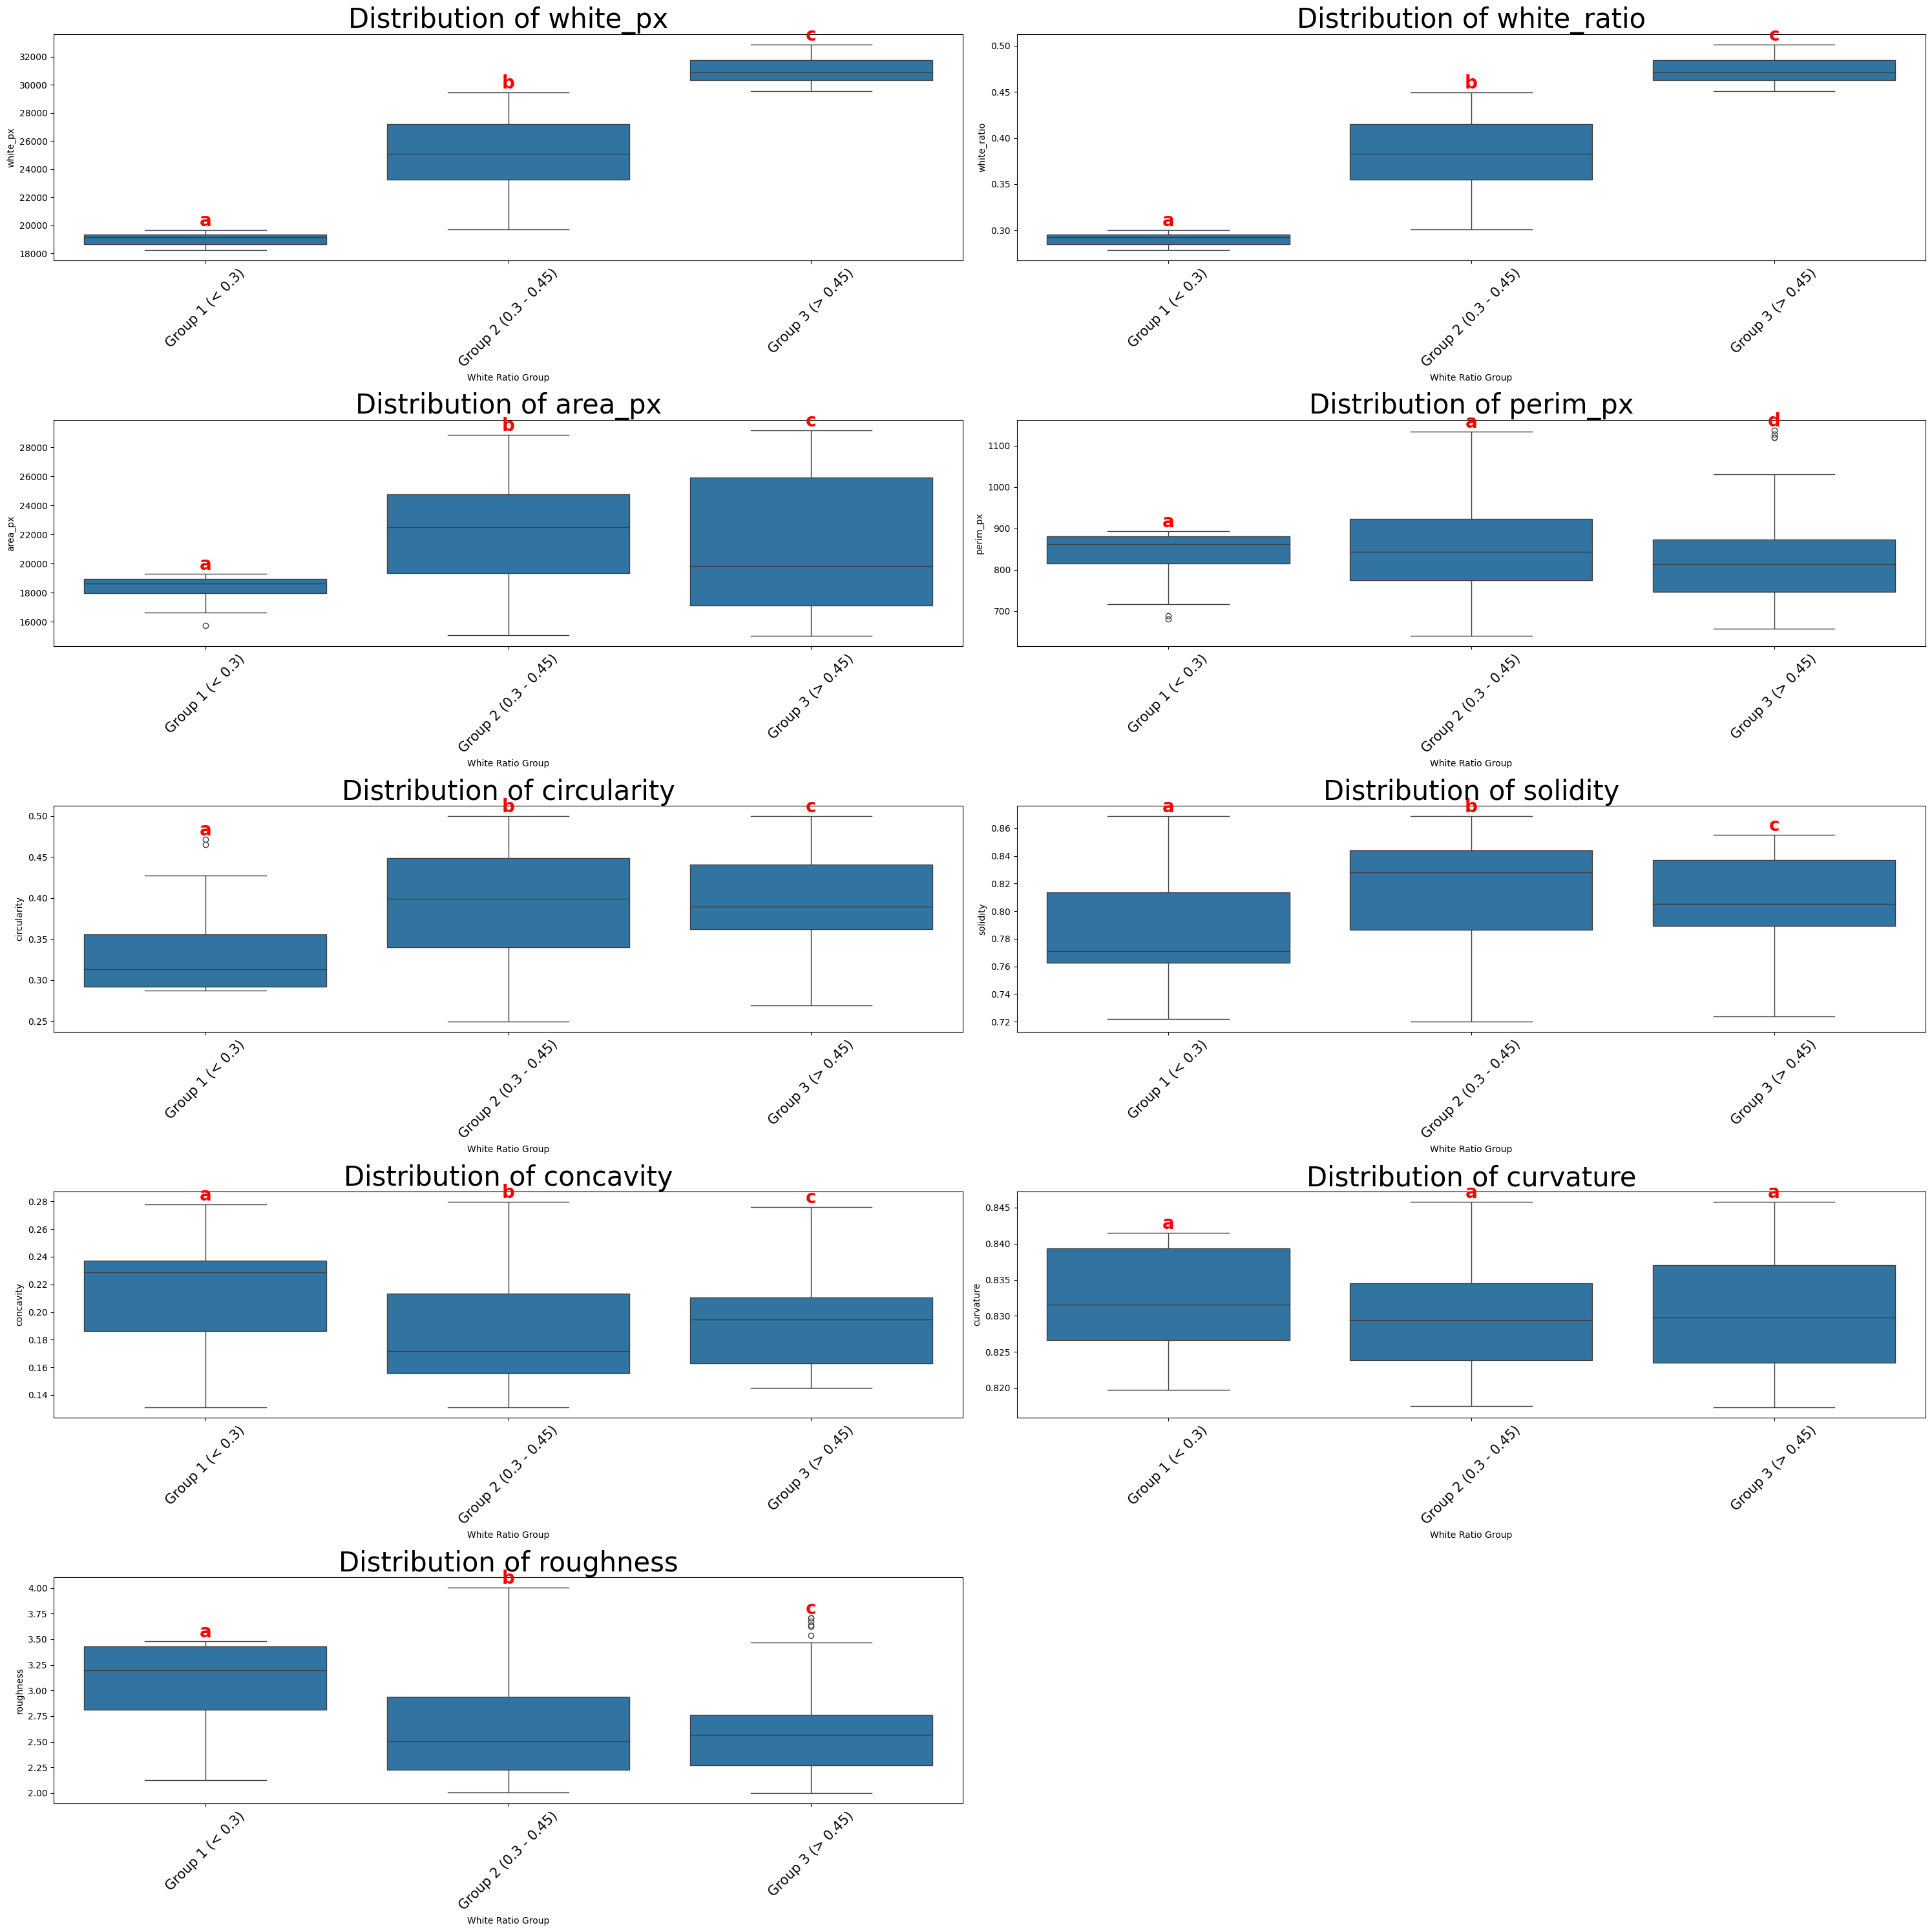

In [26]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Filter the data by removing the top and bottom 10% for each feature
df_filtered_overall = pd.DataFrame()
for col in feature:
    lower_bound = df[col].quantile(0.1)
    upper_bound = df[col].quantile(0.9)
    df_col_filtered = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)].copy()
    if df_filtered_overall.empty:
        df_filtered_overall = df_col_filtered
    else:
        df_filtered_overall = pd.merge(df_filtered_overall, df_col_filtered, on=df.columns.tolist(), how='inner')

# Define the groups based on 'white_ratio' using the filtered data
def group_white_ratio(ratio):
    if ratio < 0.3:
        return 'Group 1 (< 0.3)'
    elif 0.3 <= ratio < 0.45:
        return 'Group 2 (0.3 - 0.45)'
    else:
        return 'Group 3 (> 0.45)'

df_filtered_overall['white_ratio_group'] = df_filtered_overall['white_ratio'].apply(group_white_ratio)

# Visualize using box plots and add Tukey test results
fig, axes = plt.subplots(5, 2, figsize=(30, 30))
axes = axes.flatten()
group_order = ['Group 1 (< 0.3)', 'Group 2 (0.3 - 0.45)', 'Group 3 (> 0.45)']

for i, col in enumerate(feature):
    sns.boxplot(x='white_ratio_group', y=col, data=df_filtered_overall, order=group_order, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}', fontsize=30)
    axes[i].set_xlabel('White Ratio Group')
    axes[i].set_ylabel(col)
    axes[i].tick_params(axis='x', rotation=45, labelsize=15) # Rotate labels for better readability

    # Perform Tukey's HSD test
    try:
        tukey_result = pairwise_tukeyhsd(endog=df_filtered_overall[col], groups=df_filtered_overall['white_ratio_group'], alpha=0.05)

        # Add significance letters to the plot
        # This is a simplified approach and might need adjustment based on the exact Tukey output
        # For more complex cases, you might need a dedicated library or manual annotation
        tukey_summary = pd.DataFrame(data=tukey_result._results_table.data[1:], columns=tukey_result._results_table.data[0])
        sig_groups = {}
        for _, row in tukey_summary.iterrows():
            group1, group2, reject = row['group1'], row['group2'], row['reject']
            if not reject:
                # If groups are not significantly different, assign them the same letter
                if group1 not in sig_groups and group2 not in sig_groups:
                    next_letter = chr(ord('a') + len(sig_groups))
                    sig_groups[group1] = next_letter
                    sig_groups[group2] = next_letter
                elif group1 not in sig_groups:
                    sig_groups[group1] = sig_groups[group2]
                elif group2 not in sig_groups:
                    sig_groups[group2] = sig_groups[group1]
            else:
                # If groups are significantly different, assign them different letters
                if group1 not in sig_groups:
                     sig_groups[group1] = chr(ord('a') + len(sig_groups))
                if group2 not in sig_groups:
                     sig_groups[group2] = chr(ord('a') + len(sig_groups))
                elif sig_groups[group1] == sig_groups[group2]:
                     sig_groups[group2] = chr(ord('a') + len(sig_groups))


        # Position and add labels
        for x_pos, group in enumerate(group_order):
            if group in sig_groups:
                # Find the maximum y value for the group to position the label
                y_max = df_filtered_overall[df_filtered_overall['white_ratio_group'] == group][col].max()
                axes[i].text(x_pos, y_max, sig_groups[group], ha='center', va='bottom', color='red', fontsize=20, fontweight='bold')

    except ValueError as e:
        print(f"Could not perform Tukey test for {col}: {e}")
        # Handle cases where Tukey test is not applicable (e.g., only one group)
        pass


# Remove any unused subplots
for j in range(len(feature), len(axes)):
    fig.delaxes(axes[j])


plt.tight_layout()
plt.show()